In [1]:
import numpy as np
import pandas as pd

In [2]:
lambda25 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_2.5_results.tsv", sep="\t")
lambda25["lambda"] = [2.5 for i in range(len(lambda25))]

In [3]:
lambda30 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_3.0_results.tsv", sep="\t")
lambda30["lambda"] = [3.0 for i in range(len(lambda30))]

In [4]:
lambda35 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_3.5_results.tsv", sep="\t")
lambda35["lambda"] = [3.5 for i in range(len(lambda35))]

In [5]:
lambda40 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_4.0_results.tsv", sep="\t")
lambda40["lambda"] = [4.0 for i in range(len(lambda40))]

In [6]:
lambda45 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_4.5_results.tsv", sep="\t")
lambda45["lambda"] = [4.5 for i in range(len(lambda45))]

In [7]:
lambda50 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_5.0_results.tsv", sep="\t")
lambda50["lambda"] = [5.0 for i in range(len(lambda50))]

In [8]:
df = pd.concat([lambda25, lambda30, lambda35, lambda40, lambda45, lambda50], ignore_index=True)

In [9]:
df = df[df["SCD"] > 20.0]

In [10]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

/tmp/SLURM_1156169/ipykernel_1993385/968112340.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lambda', y=metric, ax=ax, palette="Set2", order=lambda_order)
/tmp/SLURM_1156169/ipykernel_1993385/968112340.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lambda', y=metric, ax=ax, palette="Set2", order=lambda_order)
/tmp/SLURM_1156169/ipykernel_1993385/968112340.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lambda', y=metric, ax=ax, palette="Set2", order=lambda_order)
/tmp/SLURM_1156169/ipyker

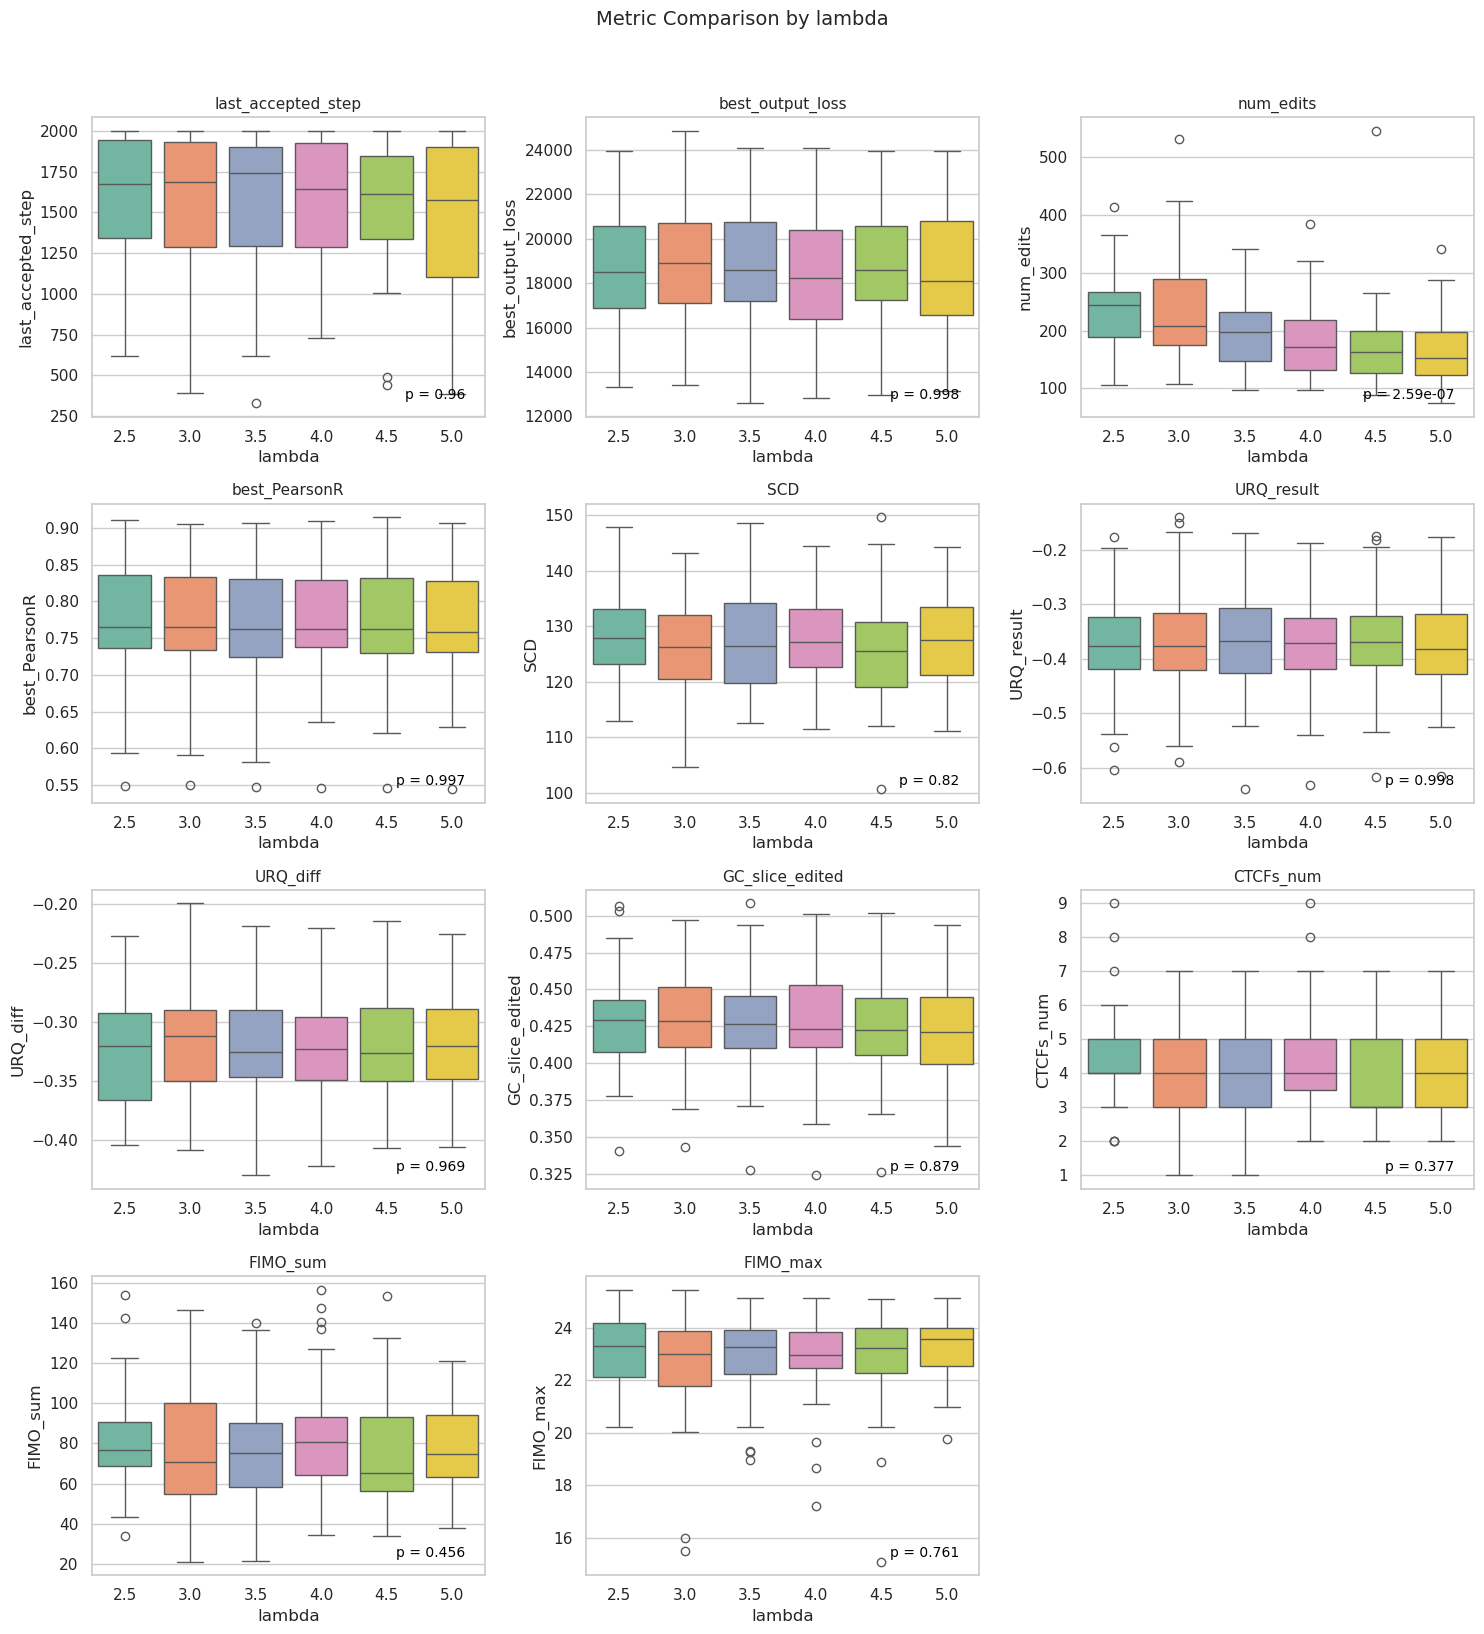

In [12]:
# Define metrics and tau order
metrics = [
    'last_accepted_step', 'best_output_loss', 'num_edits', 'best_PearsonR',
    'SCD', 'URQ_result', 'URQ_diff', 'GC_slice_edited',
    'CTCFs_num', 'FIMO_sum', 'FIMO_max'
]

# Optional: make sure tau is float
df['lambda'] = df['lambda'].astype(float)

# Sort tau values for consistent order in plots
lambda_order = sorted(df['lambda'].unique())

# Set up grid
n_cols = 3
n_rows = -(-len(metrics) // n_cols)

sns.set(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df, x='lambda', y=metric, ax=ax, palette="Set2", order=lambda_order)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("lambda")
    ax.set_ylabel(metric)

    # Kruskal-Wallis test across all tau groups
    try:
        groups = [df[df['lambda'] == l][metric].dropna() for l in lambda_order]
        if all(len(g) > 0 for g in groups):
            stat, pval = kruskal(*groups)
            ax.text(0.95, 0.05, f"p = {pval:.3g}", ha='right', va='bottom',
                    transform=ax.transAxes, fontsize=10, color='black')
        else:
            ax.text(0.95, 0.05, "p = N/A", ha='right', va='bottom',
                    transform=ax.transAxes, fontsize=10, color='gray')
    except ValueError:
        ax.text(0.95, 0.05, "p = N/A", ha='right', va='bottom',
                transform=ax.transAxes, fontsize=10, color='gray')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Metric Comparison by lambda", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [13]:
avg_edits_per_lambda = df.groupby('lambda')['num_edits'].mean().reset_index()
print(avg_edits_per_lambda)

   lambda   num_edits
0     2.5  235.704545
1     3.0  233.826087
2     3.5  197.046512
3     4.0  185.744186
4     4.5  176.000000
5     5.0  162.204545
